# Cats vs Dogs Image Classification

## Abstract

This notebook trains a convolutional neural network (CNN) to distinguish cats from dogs using the `PetImages` dataset. It covers dataset setup, preprocessing, model construction, training, evaluation, and inference.

## Project Overview

- Dataset path: `C:\Datamites\AI DATASETS\Cats-Dogs-2\PetImages`
- Classes: `Cat` and `Dog`
- Uses `ImageDataGenerator` with a validation split
- Builds a sequential CNN with convolution, pooling, dense, and dropout layers
- Trains for 10 epochs and saves the model to `cats_dogs_model.h5`
- Includes a sample image prediction example

---

In [30]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


Install TensorFlow before running the notebook. If TensorFlow is already installed in your environment, this cell can be skipped.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense   
from tensorflow.keras.layers import Dropout

Import NumPy and Matplotlib for data handling and plotting, TensorFlow for model training, and Keras layers for building the CNN.

In [51]:
import os

Import the OS module so we can access the dataset folders and verify the directory structure.

In [52]:
data_dir = r"C:\Datamites\AI DATASETS\Cats-Dogs-2\PetImages"
classes = sorted(os.listdir(data_dir))
print("Classes:", classes)

Classes: ['Cat', 'Dog']


Set the dataset path and list the class folders. This verifies that the dataset contains `Cat` and `Dog` subdirectories.

In [53]:
train_datagen = ImageDataGenerator(
                    rescale=1./255,
                    validation_split=0.2
                )

Create an image data generator that rescales image pixels from 0-255 to 0-1 and reserves 20% of the data for validation.

In [54]:
train_data = train_datagen.flow_from_directory(
                    "C:\Datamites\AI DATASETS\Cats-Dogs-2\PetImages",
                    target_size=(128,128),
                    batch_size=32,
                    class_mode='binary',
                    subset='training'
                )

Found 20000 images belonging to 2 classes.


Load the training images from the dataset, resize them to 128x128 pixels, and set up binary labels for cat/dog classification.

In [55]:
validation_data = train_datagen.flow_from_directory(
                        'C:\Datamites\AI DATASETS\Cats-Dogs-2\PetImages',
                        target_size=(128,128),
                        batch_size=32,
                        class_mode='binary',
                        subset='validation'
                    )

Found 4998 images belonging to 2 classes.


Create the validation data generator using the same preprocessing settings so we can evaluate the model on unseen data.

In [56]:
print(train_data.class_indices)

{'Cat': 0, 'Dog': 1}


Print the class-to-label mapping that the generator creates for the directory classes.

In [57]:
model = Sequential()

model.add(Conv2D(
            32,
            (3,3),
            activation='relu',
            input_shape=(128,128,3)
         ))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(
            64,
            (3,3),
            activation='relu'
         ))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(
            128,
            activation='relu'
         ))

model.add(Dropout(0.5))

model.add(Dense(
            1,
            activation='sigmoid'
         ))

Define the CNN architecture for binary image classification. It uses convolutional layers, pooling, a flatten layer, and a final sigmoid output.

In [58]:
model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
)

Compile the model with the Adam optimizer, binary crossentropy loss, and accuracy metric, which are standard for binary classification.

In [59]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Display the model summary so you can inspect the layer structure and number of trainable parameters.

In [60]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 239s 379ms/step - accuracy: 0.6288 - loss: 0.6565 - val_accuracy: 0.7013 - val_loss: 0.5889
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 241s 386ms/step - accuracy: 0.7373 - loss: 0.5328 - val_accuracy: 0.7563 - val_loss: 0.5057
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 258s 412ms/step - accuracy: 0.7937 - loss: 0.4408 - val_accuracy: 0.7725 - val_loss: 0.4837
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 414ms/step - accuracy: 0.8436 - loss: 0.3538 - val_accuracy: 0.7801 - val_loss: 0.4893
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 417ms/step - accuracy: 0.8870 - loss: 0.2681 - val_accuracy: 0.7771 - val_loss: 0.5319
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 276s 442ms/step - accuracy: 0.9299 - loss: 0.1796 - val_accuracy: 0.7735 - val_loss: 0.5756
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 239ms/step - accuracy: 0.9528 - loss: 0.1272 - val_accuracy: 0.7651 - val_loss: 0.7586
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 123s 197ms/step - accuracy: 0.9656 -

Train the model for 10 epochs while validating on the holdout data. Metrics are stored in `history` for later plotting.

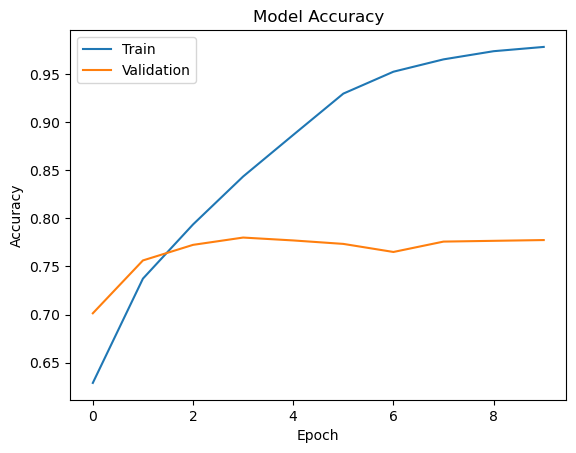

In [61]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

Plot the training and validation accuracy to see how the model improves and whether it is generalizing well.

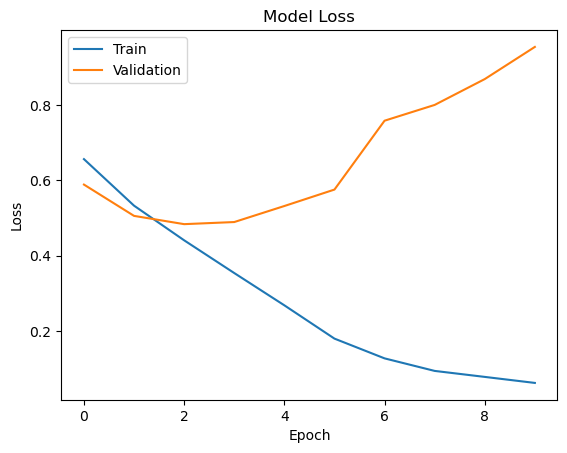

In [62]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

Plot the training and validation loss to check for underfitting or overfitting during training.

In [63]:
model.save('cats_dogs_model.h5')

Save the trained model to a file so it can be reused later without retraining.

In [67]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
        'C:\Datamites\AI DATASETS\Cats-Dogs-2\PetImages\image copy.png',
        target_size=(128,128)
      )

img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Dog


Load a sample image, preprocess it into the same shape as training data, and use the trained model to predict cat or dog.

## Project Summary

This project builds a binary image classification model for cats and dogs using the `PetImages` dataset. The notebook demonstrates:

- installing TensorFlow and setting up dependencies
- importing libraries and dataset files
- using `ImageDataGenerator` for preprocessing and validation splitting
- building a CNN with convolution, pooling, dense, and dropout layers
- compiling the model with `adam` optimizer and `binary_crossentropy` loss
- training the model and visualizing accuracy and loss curves
- saving the trained model as `cats_dogs_model.h5`
- making predictions on a new sample image

Known issue: If training fails, check for corrupted image files in `Cat/` and `Dog/` directories and remove any unreadable images.